In [1]:
from tqdm import tqdm
from service.preprocess.generate_matrix import normalizer
from port.query_structure import GenerateQueryStructure
from functools import reduce

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dask.dataframe as dd
import config
import pickle
import re
import warnings
warnings.filterwarnings("ignore")

In [2]:
def extract_name(data):
    match = re.search(r'\((.*?)\)', data)
    return match.group(1) if match else data

def compute_score(data):

    x = data.sort_values(ascending=True)
    max_val = len(x)

    if max_val <= 10:
        return np.nan
    else:
        return (x - 1) * (99 / (max_val - 1)) + 1

def assign_quantile(x):
    if 1 <= x <= 20:
        return 'Q1'
    elif 21 <= x <= 40:
        return 'Q2'
    elif 41 <= x <= 60:
        return 'Q3'
    elif 61 <= x <= 80:
        return 'Q4'
    elif 81 <= x <= 100:
        return 'Q5'
    else:
        return 'Out_of_range'
    
def calc_factor_returns(factor_name, data, ascending_order):

    result_fld = data[data['fld'] == factor_name].reset_index(drop=True)
    result_fld['lval'] = result_fld.groupby('gvkeyiid')['val'].shift(1)
    result_fld = result_fld.rename(columns={'lval': result_fld['fld'].iloc[0]})
    result_fld = result_fld.dropna(subset=[result_fld['fld'].iloc[0]])
    result_fld = result_fld.drop(columns=['val', 'fld'])

    if len(result_fld) <= 100:
        print(factor_name)
        return None, None, None, None

    else:

        result_rtn = result_query[result_query['fld'] == 'M_RETURN'].reset_index(drop=True)
        result_rtn = result_rtn.rename(columns={'val': result_rtn['fld'].iloc[0]})
        result_rtn = result_rtn.drop(columns=['fld'])

        result_df = pd.merge(result_fld, result_rtn, on=['gvkeyiid', 'ticker', 'isin', 'ddt', 'sec', 'country'], how='inner')
        result_df = result_df[result_df['sec'] != 'Undefined'].reset_index(drop=True)

        result_df['rank'] = result_df.groupby(['ddt', 'sec'])[result_df.columns[11]].rank(method='average', ascending=ascending_order)
        result_df['score'] = result_df.groupby(['ddt', 'sec'])['rank'].transform(compute_score)
        result_df['score'] = np.round(result_df['score'], 1)
        result_df['quantile'] = result_df['score'].apply(assign_quantile)

        result_sec = result_df.groupby(['ddt', 'sec', 'quantile'])['M_RETURN'].mean().unstack()
        result_quantile = result_df.groupby(['ddt', 'quantile'])['M_RETURN'].mean().unstack()
        
        if set('Out_of_range').issubset(result_sec.columns):

            result_sec = result_sec.drop(columns=['Out_of_range'])
            result_quantile = result_quantile.drop(columns=['Out_of_range'])
        else:
            pass

        result_sec = result_sec.fillna(0)
        result_sec = result_sec.groupby('sec').mean().T * 100

        result_quantile = result_quantile.fillna(0)

        result_spread = pd.DataFrame({f'{factor_name}': result_quantile.iloc[:,1] - result_quantile.iloc[:,-1]})

        first_date = result_spread.index[0]
        init_date = first_date - pd.DateOffset(months=1)
        init_df = pd.DataFrame({f'{factor_name}': [0.0]}, index=[init_date])

        result_spread = pd.concat([result_spread, init_df], axis=0).sort_index(ascending=True)

        return result_sec, result_quantile, result_spread, result_df
    
def plot_factor_returns(data, factor_name, mode):

    if mode == 'Factor Return':
        data['cum'] = (1 + data[f'{factor_name}']).cumprod()
        plt.figure(figsize=(12, 6))
        plt.title(f'{factor_name} Cumulative Return Performance')
        plt.plot(data.index, (data['cum'] - 1) * 100, color='black')
        plt.show()
    
    elif mode == 'Sector Return Histogram':
        quantiles = data.index.tolist()          # ['Q1', 'Q2', ..., 'Q5']
        sectors = data.columns.tolist()          # ['Tech', 'Energy', ...]

        bar_width = 0.15
        x = np.arange(len(sectors))
        colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

        fig, ax = plt.subplots(figsize=(12, 6))


        for i, quantile in enumerate(quantiles):
            values = data.loc[quantile].values
            offset = (i - 2) * bar_width
            ax.bar(
                x + offset,
                values,
                width=bar_width,
                label=quantile,
                color=colors[i],
                edgecolor='black'
            )

        ax.set_xticks(x)
        ax.set_xticklabels(sectors, rotation=45, ha='right')
        ax.set_ylabel('Return (%)')
        ax.set_title(f'{factor_name} Sector Quantile Grouped Bar Chart')
        ax.legend(title='Quantile')
        plt.tight_layout()
        plt.show()

    else:
        # Annualized Return by Quantile - Bar
        df_result_mean = data.mean(axis=0).to_frame()
        df_result_mean = df_result_mean.rename(columns={0: 'Avg Return(%)'})
        df_result_mean = df_result_mean.sort_index(ascending=True)

        plt.figure(figsize=(12, 6))
        plt.bar(df_result_mean.index, df_result_mean['Avg Return(%)'] * 100 * 12, color='blue')
        plt.xlabel('Quantile')
        plt.ylabel('AvgReturn(%)')
        plt.title('Annualized Average Return % by Quantile')
        plt.plot()
        plt.show()

In [3]:
factor_df = pd.read_csv("result_factor_rtn.csv")
factor_df = factor_df.rename(columns={'Unnamed: 0': 'Date'})

factor_if = pd.read_csv("factor_master.csv")

# with open("list_quantile.pkl", "rb") as f:
#     list_quantile = pickle.load(f)

# with open("list_sector.pkl", "rb") as f:
#     list_sector = pickle.load(f)

with open("list_factor_name.pkl", "rb") as f:
    list_factor_name = pickle.load(f)

with open("list_full_name.pkl", "rb") as f:
    list_full_name = pickle.load(f)

# with open("list_returns.pkl", "rb") as f:
#     list_raw_returns = pickle.load(f)

with open("list_style_name.pkl", "rb") as f:
    list_style_name = pickle.load(f)

with open("list_raw.pkl", "rb") as f:
    list_raw = pickle.load(f)

In [4]:
def custom_sequantile(factor_name, data):

    result_sec = data.groupby(['ddt', 'sec', 'quantile'])['M_RETURN'].mean().unstack()
    result_quantile = data.groupby(['ddt', 'quantile'])['M_RETURN'].mean().unstack()

    if set('Out_of_range').issubset(result_sec.columns):

        result_sec = result_sec.drop(columns=['Out_of_range'])
        result_quantile = result_quantile.drop(columns=['Out_of_range'])
    else:
        pass

    result_sec = result_sec.fillna(0)
    result_sec = result_sec.groupby('sec').mean().T * 100

    result_quantile = result_quantile.fillna(0)

    result_spread = pd.DataFrame({f'{factor_name}': result_quantile.iloc[:,1] - result_quantile.iloc[:,-1]})

    first_date = result_spread.index[0]
    init_date = first_date - pd.DateOffset(months=1)
    init_df = pd.DataFrame({f'{factor_name}': [0.0]}, index=[init_date])

    result_spread = pd.concat([result_spread, init_df], axis=0).sort_index(ascending=True)

    return result_sec, result_quantile, result_spread

def compute_label(data, factor_name):

    if data is None:
        return None

    else:
        result_label = data.groupby(['ddt', 'label'])['M_RETURN'].mean().unstack()
        result_label = result_label.fillna(0)
        result_spread = pd.DataFrame({f'{factor_name}': result_label.iloc[:, -1] - result_label.iloc[:, 0]})

        return result_label, result_spread

def corr_when_negative(factor_rets: pd.DataFrame, 
                       min_obs: int = 20) -> pd.DataFrame:
    """
    For each factor `f`, compute the correlation between `f` and *all* factors
    using only the rows where `f` has a negative return.

    Parameters
    ----------
    factor_rets : DataFrame
        Index = date, columns = factor names, values = periodic returns.
    min_obs : int, default 20
        Minimum number of observations required to compute a correlation.
        If the negative-return sample for a driver factor is smaller than
        `min_obs`, the result for that driver is set to NaN.

    Returns
    -------
    DataFrame
        Rows   = driver factor (the one conditioned on being < 0)
        Cols   = target factor (correlation with the driver)
        Values = Pearson correlation using the filtered rows.
    """
    factors = factor_rets.columns
    # initialise an empty results frame
    out = pd.DataFrame(index=factors, columns=factors, dtype=float)

    for f in factors:
        mask = factor_rets[f] < 0                # rows where driver factor is negative
        if mask.sum() < min_obs:                 # not enough data
            out.loc[f, :] = np.nan
            continue

        sub = factor_rets.loc[mask]              # restricted sample
        corr_row = sub.corr()[f]                 # correlation vs all factors
        out.loc[f, :] = corr_row

    return out

def drawdown(df):
    roll_max = df.cummax()
    daily_dd = df / roll_max - 1.0
    daily_dd.iloc[0:2] = 0
    daily_dd_max = daily_dd.cummin()
    return daily_dd, daily_dd_max

def grid_backtest(df, port, candidate, w, f):

    wgt_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    wgt_df[port['factorAbbreviation'][0]] = w
    wgt_df[candidate['factorAbbreviation'][f]] = 1 - w
    port_rtn = df * wgt_df
    port_rtn['port'] = port_rtn.sum(axis=1)
    port_rtn['cum'] = (1 + port_rtn['port']).cumprod()

    return port_rtn['cum'].iloc[-1:, ].values ** (12 / 90) - 1, drawdown(port_rtn['cum'])[1][-1:].values, port_rtn


def get_port_wgt(factor_rets, data_raw, data_neg, new_raw, factor_name, port_number, port_weight, end_date):

    norr = data_neg.loc[data_raw['factorAbbreviation'], :].T.reset_index().reset_index()
    norr.iloc[:,0] = norr.iloc[:,0] + 1
    norr.columns = ['rank_cagr', 'factorAbbreviation', norr.columns[-1]]
    norr['rank_norr'] = norr[norr.columns[-1]].rank(ascending=True)
    norr['rank_avg'] = norr['rank_cagr'] * 0.7 + norr['rank_norr'] * 0.3
    norr['rank_candidate'] = norr['rank_avg'].rank()
    norr_candidate = norr[norr['rank_candidate'] <= 5].reset_index(drop=True)

    list_main_port_wgt = []
    list_subb_port_wgt = []
    list_main_port_cagr = []
    list_subb_port_cagr = []
    list_mixx_port_cagr = []
    list_main_port_mdd = []
    list_subb_port_mdd = []
    list_mixx_port_mdd = []
    list_subb_factor_name = []
    list_port = []

    for f in range(0, 5):
        port_df = factor_rets[[data_raw['factorAbbreviation'][0], norr_candidate['factorAbbreviation'][f]]]
        port_df_cum = (1 + port_df).cumprod()
        mdd = drawdown(port_df_cum)[1][-1:].values
        cagr = port_df_cum[-1:].values ** (12 / 90) - 1

        for i in np.arange(0, 1, 0.01):

            res_bt = grid_backtest(port_df, data_raw, norr_candidate, i, f)
            list_main_port_wgt.append(i)
            list_subb_port_wgt.append(1 - i)
            list_main_port_cagr.append(cagr[0][0])
            list_subb_port_cagr.append(cagr[0][1])
            list_mixx_port_cagr.append(res_bt[0][0])
            list_main_port_mdd.append(mdd[0][0])
            list_subb_port_mdd.append(mdd[0][1])
            list_mixx_port_mdd.append(res_bt[1][0])
            list_subb_factor_name.append(norr_candidate['factorAbbreviation'][f])
            list_port.append(res_bt[2])
    
    df_mix = pd.DataFrame({
        "main_wgt"   : list_main_port_wgt,
        "sub_wgt"    : list_subb_port_wgt,
        "main_cagr"  : list_main_port_cagr,
        "sub_cagr"   : list_subb_port_cagr,
        "mix_cagr"   : list_mixx_port_cagr,
        "main_mdd"   : list_main_port_mdd,
        "sub_mdd"    : list_subb_port_mdd,
        "mix_mdd"    : list_mixx_port_mdd,
        "sub_factor" : list_subb_factor_name})

    df_mix['rank_cagr'] = df_mix['mix_cagr'].rank(ascending=False)
    df_mix['rank_mdd'] = df_mix['mix_mdd'].rank(ascending=False)
    df_mix['rank_total'] = df_mix['rank_cagr'] * 0.6 + df_mix['rank_mdd'] * 0.4

    result_sort = df_mix.sort_values('rank_total').reset_index(drop=True)
    main_port = data_raw['factorAbbreviation'].tolist()[0]
    sub_port = result_sort['sub_factor'][0]
    main_wgt = np.round(result_sort['main_wgt'][0], 2)
    sub_wgt = np.round(result_sort['sub_wgt'][0], 2)

    return df_mix, list_port, main_port, main_wgt, sub_port, sub_wgt

def get_final_port_raw(factor_rets, data_raw, data_neg, new_raw, factor_name, port_number, port_weight, end_date):

    norr = data_neg.loc[data_raw['factorAbbreviation'], :].T.reset_index().reset_index()
    norr.iloc[:,0] = norr.iloc[:,0] + 1
    norr.columns = ['rank_cagr', 'factorAbbreviation', norr.columns[-1]]
    norr['rank_norr'] = norr[norr.columns[-1]].rank(ascending=True)
    norr['rank_avg'] = norr['rank_cagr'] * 0.7 + norr['rank_norr'] * 0.3
    norr['rank_candidate'] = norr['rank_avg'].rank()
    norr_candidate = norr[norr['rank_candidate'] <= 5].reset_index(drop=True)

    list_main_port_wgt = []
    list_subb_port_wgt = []
    list_main_port_cagr = []
    list_subb_port_cagr = []
    list_mixx_port_cagr = []
    list_main_port_mdd = []
    list_subb_port_mdd = []
    list_mixx_port_mdd = []
    list_subb_factor_name = []
    list_port = []

    for f in range(0, 5):
        port_df = factor_rets[[data_raw['factorAbbreviation'][0], norr_candidate['factorAbbreviation'][f]]]
        port_df_cum = (1 + port_df).cumprod()
        mdd = drawdown(port_df_cum)[1][-1:].values
        cagr = port_df_cum[-1:].values ** (12 / 90) - 1

        for i in np.arange(0, 1, 0.01):

            res_bt = grid_backtest(port_df, data_raw, norr_candidate, i, f)
            list_main_port_wgt.append(i)
            list_subb_port_wgt.append(1 - i)
            list_main_port_cagr.append(cagr[0][0])
            list_subb_port_cagr.append(cagr[0][1])
            list_mixx_port_cagr.append(res_bt[0][0])
            list_main_port_mdd.append(mdd[0][0])
            list_subb_port_mdd.append(mdd[0][1])
            list_mixx_port_mdd.append(res_bt[1][0])
            list_subb_factor_name.append(norr_candidate['factorAbbreviation'][f])
            list_port.append(res_bt[2])
    
    df_mix = pd.DataFrame({
        "main_wgt"   : list_main_port_wgt,
        "sub_wgt"    : list_subb_port_wgt,
        "main_cagr"  : list_main_port_cagr,
        "sub_cagr"   : list_subb_port_cagr,
        "mix_cagr"   : list_mixx_port_cagr,
        "main_mdd"   : list_main_port_mdd,
        "sub_mdd"    : list_subb_port_mdd,
        "mix_mdd"    : list_mixx_port_mdd,
        "sub_factor" : list_subb_factor_name})

    df_mix['rank_cagr'] = df_mix['mix_cagr'].rank(ascending=False)
    df_mix['rank_mdd'] = df_mix['mix_mdd'].rank(ascending=False)
    df_mix['rank_total'] = df_mix['rank_cagr'] * 0.6 + df_mix['rank_mdd'] * 0.4

    result_sort = df_mix.sort_values('rank_total').reset_index(drop=True)
    main_port = data_raw['factorAbbreviation'].tolist()[0]
    sub_port = result_sort['sub_factor'][0]
    main_wgt = np.round(result_sort['main_wgt'][0], 2)
    sub_wgt = np.round(result_sort['sub_wgt'][0], 2)

    df_port_result = new_raw[factor_name.index(main_port)]
    df_port_result = df_port_result[df_port_result['ddt'] == end_date].reset_index(drop=True)
    df_port_result['port'] = port_number
    df_port_result['factor'] = main_port
    df_port_result = df_port_result[['port', 'ddt', 'ticker', 'isin', 'gvkeyiid', 'factor', 'label']]
    df_port_result = df_port_result.rename(columns={'label': 'weight'})
    df_port_result['weight'] = df_port_result['weight'] * main_wgt * port_weight * 0.01
    df_port_result['raw_weight'] = main_wgt * port_weight
    
    df_port_result_sub = new_raw[factor_name.index(sub_port)]
    df_port_result_sub = df_port_result_sub[df_port_result_sub['ddt'] == end_date].reset_index(drop=True)
    df_port_result_sub['port'] = port_number
    df_port_result_sub['factor'] = sub_port
    df_port_result_sub = df_port_result_sub[['port', 'ddt', 'ticker', 'isin', 'gvkeyiid', 'factor', 'label']]
    df_port_result_sub = df_port_result_sub.rename(columns={'label': 'weight'})
    df_port_result_sub['weight'] = df_port_result_sub['weight'] * sub_wgt * port_weight * 0.01
    df_port_result_sub['raw_weight'] = sub_wgt * port_weight

    return df_port_result, df_port_result_sub


In [ ]:
list_sector_custom = []
list_quantile_custom = []
list_returns_custom = []

for i in tqdm(range(0, len(list_raw))):
    raw_custom = list_raw[i][list_raw[i]['ddt'] >= '2018-01-31'].reset_index(drop=True)
    res_custom = custom_sequantile(list_factor_name[i], raw_custom)
    list_sector_custom.append(res_custom[0])
    list_quantile_custom.append(res_custom[1])
    list_returns_custom.append(res_custom[2])

list_factor_number = []
list_delete_factor = []

for i in tqdm(range(0, len(list_sector_custom))):

    df = list_sector_custom[i].T.reset_index()
    df['diff'] = df['Q1'] - df['Q5']
    list_factor_number.append(i)
    list_delete_factor.append(df[df['diff'] < 0]['sec'].tolist())

list_new_raw = []

for i in tqdm(range(0, len(list_raw))):
    df_sector_deleted = list_raw[i].loc[~list_raw[i]['sec'].isin(list_delete_factor[i])].reset_index(drop=True)
    df_sector_deleted = df_sector_deleted[df_sector_deleted['ddt'] >= '2018-01-31'].reset_index(drop=True)
    if len(df_sector_deleted) == 0:
        list_new_raw.append(None)
    else:
        result_quantile = df_sector_deleted.groupby(['ddt', 'quantile'])['M_RETURN'].mean().unstack()
        result_quantile = result_quantile.drop(columns=['Out_of_range'])
        result_quantile = result_quantile.fillna(0)
        qmean = result_quantile.mean(axis=0).to_frame()
        qmean.columns = ['mean']
        k = (qmean.loc['Q1', 'mean'] - qmean.loc['Q5', 'mean']) * 0.1
        qmean['long'] = (qmean['mean'] > (qmean.loc['Q1', 'mean'] - k)).astype(int)
        qmean['long'] = qmean['long'].cumprod()
        qmean['short'] = (qmean['mean'] < (qmean.loc['Q5', 'mean'] + k)).astype(int) * -1
        qmean['short'] = abs(qmean['short'])[::-1].cumprod()[::-1] * -1
        qmean['label'] = qmean['long'] + qmean['short']
        qmean = qmean.reset_index()[['quantile', 'label']]

        result_df = pd.merge(df_sector_deleted, qmean, on='quantile', how='inner')
        list_new_raw.append(result_df)

list_label = []
list_returns = [] 

for i in tqdm(range(0, len(list_new_raw)-3)):
    res = compute_label(list_new_raw[i], list_factor_name[i])
    list_label.append(res[0])
    list_returns.append(res[1])

df = pd.concat([s for s in list_returns], axis=1)
df = df.dropna(how='all')
df = df.fillna(0)

first_date = df.index[0]
init_date = first_date - pd.DateOffset(months=1)
df.loc[init_date] = 0
df = df.sort_index(ascending=True)
df = df.loc[:, (df == 0).sum() <= 10]

ranked_df = (1 + df).cumprod().iloc[-1] ** (12 / 90) - 1
ranked_df = ranked_df.to_frame()
ranked_df.columns = ['cagr']
ranked_df = ranked_df.reset_index()
ranked_df = ranked_df.rename(columns={'index': 'factorAbbreviation'})

_factor_if = factor_if[['factorAbbreviation', 'styleName']]
result_df = pd.merge(ranked_df, _factor_if, on='factorAbbreviation', how='inner')
result_df['rank_style'] = result_df.groupby('styleName')['cagr'].rank(ascending=False)
result_df['rank_total'] = result_df['cagr'].rank(ascending=False)
result_df = result_df.sort_values('rank_total').reset_index(drop=True).reset_index(drop=True)

factor_rets = df[result_df['factorAbbreviation'].tolist()]
result_negcorr = corr_when_negative(factor_rets)
desired_order = result_df['factorAbbreviation'].tolist()
df_result_neg_corr = result_negcorr.reindex(desired_order)

100%|██████████| 230/230 [00:00<00:00, 552.88it/s]


In [6]:
port_ane = result_df[(result_df['styleName'] == 'Analyst Expectations') & (result_df['rank_style'] == 1)].reset_index(drop=True)
port_mom = result_df[(result_df['styleName'] == 'Price Momentum') & (result_df['rank_style'] == 1)].reset_index(drop=True)
port_val = result_df[(result_df['styleName'] == 'Valuation') & (result_df['rank_style'] == 1)].reset_index(drop=True)
port_hig = result_df[(result_df['styleName'] == 'Historical Growth') & (result_df['rank_style'] == 1)].reset_index(drop=True)
port_caf = result_df[(result_df['styleName'] == 'Capital Efficiency') & (result_df['rank_style'] == 1)].reset_index(drop=True)
port_eaq = result_df[(result_df['styleName'] == 'Earnings Quality') & (result_df['rank_style'] == 1)].reset_index(drop=True)

res_wgt_ane = get_port_wgt(factor_rets, port_ane, df_result_neg_corr, list_new_raw, list_factor_name, 'A', 1, '2025-05-31')
res_wgt_mom = get_port_wgt(factor_rets, port_mom, df_result_neg_corr, list_new_raw, list_factor_name, 'B', 1, '2025-05-31')
res_wgt_val = get_port_wgt(factor_rets, port_val, df_result_neg_corr, list_new_raw, list_factor_name, 'C', 1, '2025-05-31')
res_wgt_hig = get_port_wgt(factor_rets, port_hig, df_result_neg_corr, list_new_raw, list_factor_name, 'D', 1, '2025-05-31')
res_wgt_caf = get_port_wgt(factor_rets, port_caf, df_result_neg_corr, list_new_raw, list_factor_name, 'E', 1, '2025-05-31')
res_wgt_eaq = get_port_wgt(factor_rets, port_eaq, df_result_neg_corr, list_new_raw, list_factor_name, 'F', 1, '2025-05-31')

port_res_wgt_ane = res_wgt_ane[1][res_wgt_ane[0].sort_values('rank_total').index[0]][['port']]
port_res_wgt_mom = res_wgt_mom[1][res_wgt_mom[0].sort_values('rank_total').index[0]][['port']]
port_res_wgt_val = res_wgt_val[1][res_wgt_val[0].sort_values('rank_total').index[0]][['port']]
port_res_wgt_hig = res_wgt_hig[1][res_wgt_hig[0].sort_values('rank_total').index[0]][['port']]
port_res_wgt_caf = res_wgt_caf[1][res_wgt_caf[0].sort_values('rank_total').index[0]][['port']]
port_res_wgt_eaq = res_wgt_eaq[1][res_wgt_eaq[0].sort_values('rank_total').index[0]][['port']]

port_res_wgt_ane.columns = ['ane']
port_res_wgt_mom.columns = ['mom']
port_res_wgt_val.columns = ['val']
port_res_wgt_hig.columns = ['hig']
port_res_wgt_caf.columns = ['caf']
port_res_wgt_eaq.columns = ['eaq']

port_res = pd.concat([port_res_wgt_ane,
                      port_res_wgt_mom,
                      port_res_wgt_val,
                      port_res_wgt_hig,
                      port_res_wgt_caf,
                      port_res_wgt_eaq], axis=1)

In [7]:
res_ane = get_final_port_raw(factor_rets, port_ane, df_result_neg_corr, list_new_raw, list_factor_name, 'A', 1/6, '2025-05-31')
res_mom = get_final_port_raw(factor_rets, port_mom, df_result_neg_corr, list_new_raw, list_factor_name, 'B', 1/6, '2025-05-31')
res_val = get_final_port_raw(factor_rets, port_val, df_result_neg_corr, list_new_raw, list_factor_name, 'C', 1/6, '2025-05-31')
res_hig = get_final_port_raw(factor_rets, port_hig, df_result_neg_corr, list_new_raw, list_factor_name, 'D', 1/6, '2025-05-31')
res_caf = get_final_port_raw(factor_rets, port_caf, df_result_neg_corr, list_new_raw, list_factor_name, 'E', 1/6, '2025-05-31')
res_eaq = get_final_port_raw(factor_rets, port_eaq, df_result_neg_corr, list_new_raw, list_factor_name, 'F', 1/6, '2025-05-31')

factor_coefficient = pd.concat([res_ane[0].iloc[0:1:,][['factor', 'raw_weight']], res_ane[1].iloc[0:1:,][['factor', 'raw_weight']], 
                                res_mom[0].iloc[0:1:,][['factor', 'raw_weight']], res_mom[1].iloc[0:1:,][['factor', 'raw_weight']],
                                res_val[0].iloc[0:1:,][['factor', 'raw_weight']], res_val[1].iloc[0:1:,][['factor', 'raw_weight']],
                                res_hig[0].iloc[0:1:,][['factor', 'raw_weight']], res_hig[1].iloc[0:1:,][['factor', 'raw_weight']],
                                res_caf[0].iloc[0:1:,][['factor', 'raw_weight']], res_caf[1].iloc[0:1:,][['factor', 'raw_weight']],
                                res_eaq[0].iloc[0:1:,][['factor', 'raw_weight']], res_eaq[1].iloc[0:1:,][['factor', 'raw_weight']]], axis=0).reset_index(drop=True)


factor_coefficient_result = factor_coefficient.groupby(['factor'], as_index=False).agg({'raw_weight': 'sum'})
factor_if__ = factor_if[['factorAbbreviation', 'styleName']]
factor_if__ = factor_if__.rename(columns={'factorAbbreviation': 'factor'})

rs = pd.merge(factor_coefficient_result, factor_if__, on='factor', how='inner')
rs = rs.sort_values('raw_weight', ascending=False).reset_index(drop=True)

In [8]:
rtn_df = list_returns[list_factor_name.index(rs['factor'][0])]
for i in range(1, len(rs)):
    inv_df = list_returns[list_factor_name.index(rs['factor'][i])]
    rtn_df = pd.concat([rtn_df, inv_df], axis=1)

first_date = rtn_df.index[0]
init_date = first_date - pd.DateOffset(months=1)
rtn_df.loc[init_date] = 0
rtn_df = rtn_df.sort_index(ascending=True)

In [9]:
K = len(rtn_df.columns)
R = 20_000_000
mat = np.random.rand(K, R)
mat = mat.astype(np.float64)

In [10]:
# K = len(rtn_df.columns)
# R = 20_000_000
# mat = np.random.rand(K, R)

col_sum   = mat.sum(axis=0, keepdims=True)
mat_norm  = mat / col_sum

K, R = mat_norm.shape
styles= np.array(rs['styleName'].tolist())
unique_styles = np.unique(styles)
S = len(unique_styles)

In [11]:
mask = np.zeros((S, K), dtype=int)
for i, s in enumerate(unique_styles):
    mask[i, styles == s] = 1

In [12]:
cap = 0.25

style_share = mask @ mat_norm
excess = np.clip(style_share - cap, a_min=0, a_max=None)
scale = np.where(style_share > cap, cap / style_share, 1.0)
shrink_factor = (mask.T @ scale)

In [13]:
mat_scaled = mat_norm * shrink_factor

In [14]:
room = np.where(style_share < cap, style_share, 0)
room_sum = room.sum(axis=0, keepdims=True)

In [15]:
redistrib_ratio = np.divide(room, room_sum, where=room_sum!=0)

In [16]:
add_amount = excess.sum(axis=0, keepdims=True) * redistrib_ratio

In [17]:
mat_final = mat_scaled + (mask.T @ add_amount)
mat_final /= mat_final.sum(axis=0, keepdims=True)

In [18]:
tol = 1e-12

ok_cols = (style_share <= cap + tol).all(axis=0)

In [19]:
mat_final = mat_final[:, ok_cols]
mat_final.shape

(7, 3298796)

In [20]:
assert np.allclose(mat_final.sum(axis=0), 1.0, atol=1e-4)

In [21]:
assert (mask @ mat_final <= cap + 1e-4).all()

In [22]:
# np_port   = np.array(rtn_df)

In [23]:
np_port = np.array(rtn_df, dtype=np.float16)
np_sim = np_port @ mat_final

ddf = pd.DataFrame(data=np_sim, index=port_res.index)
sim_cum = (1 + ddf).cumprod()
sim_cagr = sim_cum.iloc[-1:] ** (12 / len(ddf)) - 1
sim_cagr = sim_cagr.T
sim_mdd = drawdown(sim_cum)[1][-1:].values
sim_mdd = sim_mdd.T
sim_tot = sim_cagr.copy()
sim_tot.columns = ['cagr']
sim_tot['mdd'] = sim_mdd
sim_tot['rank_cagr'] = sim_tot['cagr'].rank(ascending=False)
sim_tot['rank_mdd'] = sim_tot['mdd'].rank(ascending=False)
sim_tot['rank_total'] = sim_tot['rank_cagr'] * 0.6 + sim_tot['rank_mdd'] * 0.4

In [24]:
sim_tot.sort_values('rank_total').iloc[0:1]

,cagr,mdd,rank_cagr,rank_mdd,rank_total
1878645,0.101153,-0.01855,124689.0,236407.0,169376.2


In [25]:
mat_final[:, 1878645]

array([0.10646441, 0.14948113, 0.12192201, 0.24059917, 0.1858976 ,
       0.12732218, 0.0683135 ])

In [26]:
rs['fitted_weight'] = mat_final[:, 1878645]
rs

,factor,raw_weight,styleName,fitted_weight
0,Rev3MFY1C,0.280000,Analyst Expectations,0.106464
1,SalesToEPSChg,0.200000,Earnings Quality,0.149481
2,PM6M,0.163333,Price Momentum,0.121922
3,SalesAcc,0.143333,Historical Growth,0.240599
4,CashEV,0.085000,Valuation,0.185898
5,52WSlope,0.080000,Price Momentum,0.127322
6,CapAcqRatio,0.048333,Capital Efficiency,0.068314


In [38]:
a = list_new_raw[list_factor_name.index('Rev3MFY1C')]
a['weight'] = a['label'] * rs['fitted_weight'][0]
a

,gvkeyiid,ticker,isin,ddt,sec,country,factorId,factorName,factorShortName,styleName,factorOrder,Rev3MFY1C,M_RETURN,rank,score,quantile,label,weight
0,25954402W,601633,CNE1000018V8,2018-01-31,Consumer Discretionary,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,-0.028215,0.100238,81.0,98.8,Q5,-1,-0.106464
1,29864101W,601636,CNE100001666,2018-01-31,Industrials,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,0.000293,0.277606,44.0,32.1,Q2,0,0.000000
2,26012601W,601607,CNE000000C82,2018-01-31,Health Care,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,-0.000697,0.021662,36.0,67.6,Q4,0,0.000000
3,06284402W,601333,CNE000001Q44,2018-01-31,Industrials,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,0.001382,-0.057582,25.0,18.3,Q1,1,0.106464
4,29686701W,601216,CNE1000010F8,2018-01-31,Materials,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,0.000000,0.035359,53.0,55.2,Q3,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40217,27213001W,000661,CNE0000007J8,2025-05-31,Health Care,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,-0.100683,0.201474,44.0,97.8,Q5,-1,-0.106464
40218,25990401W,000598,CNE000000HN4,2025-05-31,Utilities,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,-0.007052,0.041379,10.0,47.9,Q3,0,0.000000
40219,26013001W,000423,CNE0000006Y9,2025-05-31,Health Care,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,0.002103,0.017463,3.0,5.5,Q1,1,0.106464
40220,31610001W,000333,CNE100001QQ5,2025-05-31,Consumer Discretionary,CHN,954,3M Revision in FY1 EPS Estimate,3MRevFY1,Analyst Expectations,Descending,-0.000679,0.084672,16.0,38.1,Q2,0,0.000000


In [34]:
list_quantile_custom[1]

quantile,Out_of_range,Q1,Q2,Q3,Q4,Q5
ddt,,,,,,
2018-01-31,0.049476,0.072011,0.056841,0.021770,0.027596,0.039661
2018-02-28,-0.035318,-0.035547,-0.044824,-0.049256,-0.026423,-0.045515
2018-03-31,0.019050,0.001259,0.010712,0.014415,0.009175,0.014811
2018-04-30,-0.042353,-0.024942,-0.040421,-0.056010,-0.053640,-0.062409
2018-05-31,0.012688,-0.000787,-0.005894,-0.002500,-0.009235,-0.018353
...,...,...,...,...,...,...
2025-01-31,-0.034373,-0.003692,-0.010237,-0.012613,-0.016828,-0.037756
2025-02-28,0.012384,0.016044,0.009389,0.034471,0.034272,0.011226
2025-03-31,-0.018174,0.012088,0.013753,0.008359,-0.005698,-0.009563


In [27]:
port_01 = np.array(rtn_df) @ np.array(rs['raw_weight'])
port_01_df = pd.DataFrame(data=port_01, columns=['port_01'], index=rtn_df.index)
port_02 = np.array(rtn_df) @ np.array(rs['fitted_weight'])
port_02_df = pd.DataFrame(data=port_02, columns=['port_02'], index=rtn_df.index)
port_gogo = pd.concat([port_01_df, port_02_df], axis=1)
port_gogo = port_gogo.fillna(0)

<Axes: xlabel='ddt'>

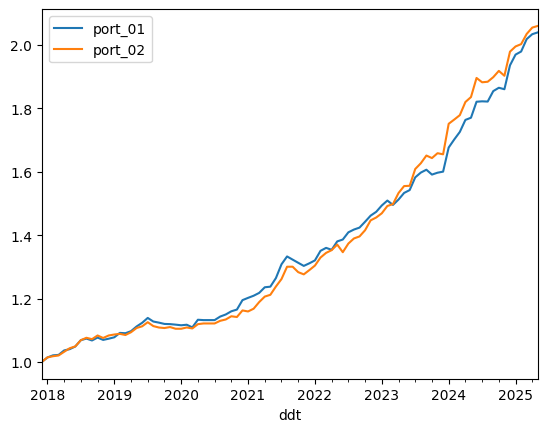

In [28]:
(1 + port_gogo).cumprod().plot()

<Axes: xlabel='ddt'>

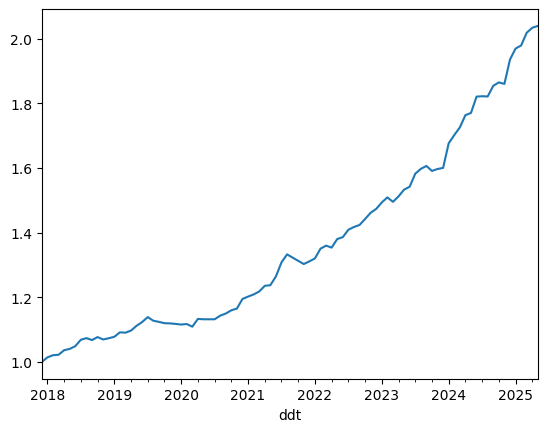

In [29]:
portcum_gogo = (1 + port_gogo).cumprod()
portcum_gogo['sp'] = portcum_gogo['port_02'] = portcum_gogo['port_01']
portcum_gogo['sp'].plot()

In [30]:
(1 + port_gogo).cumprod()[-1:] ** (12 / 90) - 1

,port_01,port_02
ddt,,
2025-05-31,0.099698,0.101153


In [31]:
dd = drawdown((1 + port_gogo).cumprod())

In [32]:
dd[1]

,port_01,port_02
ddt,,
2017-12-31,0.000000,0.000000
2018-01-31,0.000000,0.000000
2018-02-28,0.000000,0.000000
2018-03-31,0.000000,0.000000
2018-04-30,0.000000,0.000000
...,...,...
2025-01-31,-0.026158,-0.018548
2025-02-28,-0.026158,-0.018548
2025-03-31,-0.026158,-0.018548
